Regressão linear SEM aplicar nenhuma técnica de data augmentation.

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from imblearn.over_sampling import SMOTE

In [30]:
df = pd.read_csv('data/salary.csv')
df = df.drop(columns=['Unnamed: 0'])

X = df[['YearsExperience']]
y = df['Salary'].values

print(X.shape, y.shape)

(30, 1) (30,)


In [31]:
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
scaler = StandardScaler()
X_train_base = scaler.fit_transform(X_train_orig)
X_test_base = scaler.transform(X_test_orig)

In [33]:
model = LinearRegression()
model.fit(X_train_base, y_train_orig)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[27151.54]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.421e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[4.9]


In [34]:
y_pred = model.predict(X_test_base)

mse = mean_squared_error(y_test_orig, y_pred)
mae = mean_absolute_error(y_test_orig, y_pred)
r2 = r2_score(y_test_orig, y_pred)

print(f'MSE: {mse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R2: {r2:.4f}')

MSE: 49830096.86
MAE: 6286.45
R2: 0.9024


Gráfico: anos de experiência vs salário.

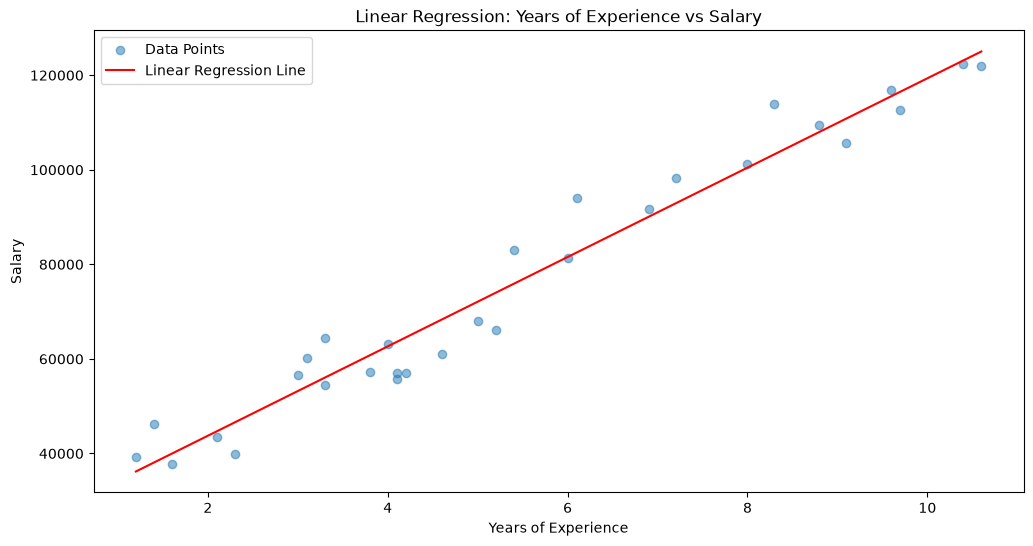

In [35]:
import matplotlib.pyplot as plt

model_plot = LinearRegression()
model_plot.fit(X, y)
y_line = model_plot.predict(X)

x_plot = X.values.ravel()

plt.figure(figsize=(12, 6))
plt.scatter(x_plot, y, alpha=0.5, label='Data Points')
plt.plot(x_plot, y_line, color='red', label='Linear Regression Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Linear Regression: Years of Experience vs Salary')
plt.legend()
plt.show()

Inserir SMOTE

1. Discretizar o alvo em classes (bins de largura igual; ajuste para o SMOTE funcionar).

In [36]:
edges = np.linspace(y_train_orig.min(), y_train_orig.max(), 6)
y_class_train = np.clip(np.digitize(y_train_orig, edges) - 1, 0, 4).astype(int)

print('Contagem por classe (treino):', np.bincount(y_class_train).tolist())

Contagem por classe (treino): [6, 8, 1, 4, 5]


2. Definir máscara de classes raras para aplicar SMOTE.

In [37]:
mask = (y_class_train == 0) | (y_class_train == 4)
mask_middle = ~mask
print('Na máscara (extremos, treino):', mask.sum(), '| meio:', mask_middle.sum())

Na máscara (extremos, treino): 11 | meio: 13


3. Aplicar SMOTE com as features contínuas padronizadas.

In [38]:
X_mask = X_train_orig.values[mask]
scaler_smote = StandardScaler()
X_mask_scaled = scaler_smote.fit_transform(X_mask)

class_counts = np.bincount(y_class_train[mask])
valid_counts = class_counts[class_counts > 0]
min_count = valid_counts.min() if len(valid_counts) > 0 else 0

if min_count > 1:
    k = min(3, min_count - 1)
    smote = SMOTE(k_neighbors=k, random_state=42)
    X_smote_scaled, y_class_smote = smote.fit_resample(X_mask_scaled, y_class_train[mask])
    X_smote = scaler_smote.inverse_transform(X_smote_scaled)
else:
    X_smote_scaled = X_mask_scaled.copy()
    y_class_smote = y_class_train[mask].copy()
    X_smote = X_mask.copy()

print('X_smote:', X_smote.shape, '(antes:', X_mask.shape, ')')

X_smote: (12, 1) (antes: (11, 1) )


4. Definir o alvo das sintéticas por interpolação local (kNN ponderado por distância).

In [39]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=3, weights='distance')
knn.fit(X_mask_scaled, y_train_orig[mask])
y_smote = knn.predict(X_smote_scaled)

orig_scaled_by_hash = {}
for i in range(len(X_mask_scaled)):
    h = X_mask_scaled[i].tobytes()
    if h not in orig_scaled_by_hash:
        orig_scaled_by_hash[h] = y_train_orig[mask][i]
y_smote = np.array([
    orig_scaled_by_hash.get(r.tobytes(), v) for r, v in zip(X_smote_scaled, y_smote)
])

5. Combinar amostras sintéticas com amostras originais do treino.

In [40]:
X_final = np.vstack([X_smote, X_train_orig.values[mask_middle]])
y_final = np.hstack([y_smote, y_train_orig[mask_middle]])
y_final_class = np.hstack([y_class_smote, y_class_train[mask_middle]]).astype(int)
print('X_final:', X_final.shape, '| y_final:', y_final.shape)

X_final: (25, 1) | y_final: (25,)


In [41]:
X_final

array([[10.4      ],
       [ 8.8      ],
       [ 1.2      ],
       [ 2.3      ],
       [ 1.4      ],
       [ 1.6      ],
       [ 9.1      ],
       [ 2.1      ],
       [ 9.6      ],
       [10.6      ],
       [ 3.3      ],
       [ 8.8610371],
       [ 4.1      ],
       [ 5.2      ],
       [ 3.       ],
       [ 4.2      ],
       [ 4.1      ],
       [ 8.       ],
       [ 7.2      ],
       [ 6.       ],
       [ 6.9      ],
       [ 4.       ],
       [ 4.6      ],
       [ 6.1      ],
       [ 3.1      ]])

6. Manter conjunto de teste fixo e preparar treino aumentado.

In [ ]:
X_train = X_final
y_train = y_final
X_test = X_test_orig.values
y_test = y_test_orig
print('Treino (SMOTE):', X_train.shape, '| Teste (fixo):', X_test.shape)

Treino (aumentado): (25, 1) | Teste (fixo): (6, 1)


7. Re-escalonar e treinar.

In [43]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[27469.53]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.561e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[5.]


8. Avaliar.

In [44]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R2: {r2:.4f}')

MSE: 49484636.75
MAE: 6291.63
R2: 0.9031


Inserir Mix-Up

1. Função MixUp.

In [45]:
def mixup(X, y, alpha=0.2, n_samples=2):
    X_mix = []
    y_mix = []

    for _ in range(n_samples):
        indices = np.arange(len(X))
        np.random.shuffle(indices)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        lam = np.random.beta(alpha, alpha)

        X_mixed = lam * X + (1 - lam) * X_shuffled
        y_mixed = lam * y + (1 - lam) * y_shuffled

        X_mix.append(X_mixed)
        y_mix.append(y_mixed)

    return np.vstack(X_mix), np.hstack(y_mix)

2. Aplicar MixUp dentro de cada grupo de classe.

In [46]:
X_mix = []
y_mix = []
cls_mix = []

for c in np.unique(y_final_class):
    X_group = X_final[y_final_class == c]
    y_group = y_final[y_final_class == c]

    X_mixed, y_mixed = mixup(X_group, y_group)

    X_mix.append(X_mixed)
    y_mix.append(y_mixed)
    cls_mix.append(np.full(len(X_mixed), c))

X_combined = np.vstack(X_mix)
y_combined = np.hstack(y_mix)
y_combined_class = np.hstack(cls_mix).astype(int)
print('X_combined:', X_combined.shape, '| y_combined:', y_combined.shape)

X_combined: (50, 1) | y_combined: (50,)


In [47]:
X_combined

array([[ 1.2       ],
       [ 1.80227423],
       [ 2.03993314],
       [ 1.45779264],
       [ 2.1       ],
       [ 3.3       ],
       [ 1.39969275],
       [ 2.10030725],
       [ 1.20030725],
       [ 1.6       ],
       [ 2.29969275],
       [ 3.3       ],
       [ 4.1       ],
       [ 4.79450465],
       [ 3.19309302],
       [ 4.2       ],
       [ 4.1       ],
       [ 3.80690698],
       [ 4.6       ],
       [ 3.50549535],
       [ 3.92659439],
       [ 5.02659439],
       [ 3.18916975],
       [ 4.18423585],
       [ 4.08423585],
       [ 4.09458488],
       [ 4.69458488],
       [ 3.1       ],
       [ 6.        ],
       [ 6.        ],
       [ 6.90110019],
       [ 6.10110019],
       [ 7.99889981],
       [ 7.19889981],
       [ 7.65752529],
       [ 7.07157198],
       [ 6.55752529],
       [ 6.91337744],
       [ 9.13656192],
       [ 8.8       ],
       [10.55781317],
       [10.37750036],
       [ 9.62812455],
       [ 8.8610371 ],
       [10.40007978],
       [ 8

3. Re-divisão em treino/teste.

In [ ]:
X_train = X_combined
y_train = y_combined
X_test = X_test_orig.values
y_test = y_test_orig
print('Treino (MixUp):', X_train.shape, '| Teste (fixo):', X_test.shape)

Treino (mixup): (50, 1) | Teste (fixo): (6, 1)


4. Re-escalonar e treinar.

In [49]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[27515.38]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.561e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[7.07]


5. Avaliar.

In [50]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R2: {r2:.4f}')

MSE: 49405818.79
MAE: 6306.70
R2: 0.9033


Inserir ruído gaussiano

1. Função para adicionar ruído gaussiano.

In [51]:
def add_gaussian_noise(X, mean=0, stddev=0.1):
    noise = np.random.normal(mean, stddev, X.shape)
    return X + noise

2. Aplicar ruído apenas nas features contínuas (σ = 10% do desvio padrão de cada feature).

In [52]:
X_noisy = []
y_noisy = []

sigma_feat = X_combined.std(axis=0) * 0.10

for c in np.unique(y_combined_class):
    idx = y_combined_class == c
    X_group = X_combined[idx].copy()
    y_group = y_combined[idx]

    X_group = add_gaussian_noise(X_group, stddev=sigma_feat)

    X_noisy.append(X_group)
    y_noisy.append(y_group)

X_final_noisy = np.vstack([X_combined] + X_noisy)
y_final_noisy = np.hstack([y_combined] + y_noisy)
print('X_final_noisy:', X_final_noisy.shape, '| y_final_noisy:', y_final_noisy.shape)

X_final_noisy: (100, 1) | y_final_noisy: (100,)


In [53]:
X_final_noisy

array([[ 1.2       ],
       [ 1.80227423],
       [ 2.03993314],
       [ 1.45779264],
       [ 2.1       ],
       [ 3.3       ],
       [ 1.39969275],
       [ 2.10030725],
       [ 1.20030725],
       [ 1.6       ],
       [ 2.29969275],
       [ 3.3       ],
       [ 4.1       ],
       [ 4.79450465],
       [ 3.19309302],
       [ 4.2       ],
       [ 4.1       ],
       [ 3.80690698],
       [ 4.6       ],
       [ 3.50549535],
       [ 3.92659439],
       [ 5.02659439],
       [ 3.18916975],
       [ 4.18423585],
       [ 4.08423585],
       [ 4.09458488],
       [ 4.69458488],
       [ 3.1       ],
       [ 6.        ],
       [ 6.        ],
       [ 6.90110019],
       [ 6.10110019],
       [ 7.99889981],
       [ 7.19889981],
       [ 7.65752529],
       [ 7.07157198],
       [ 6.55752529],
       [ 6.91337744],
       [ 9.13656192],
       [ 8.8       ],
       [10.55781317],
       [10.37750036],
       [ 9.62812455],
       [ 8.8610371 ],
       [10.40007978],
       [ 8

3. Re-divisão em treino/teste.

In [ ]:
X_train = X_final_noisy
y_train = y_final_noisy
X_test = X_test_orig.values
y_test = y_test_orig
print('Treino (ruído):', X_train.shape, '| Teste (fixo):', X_test.shape)

Treino (ruído): (100, 1) | Teste (fixo): (6, 1)


4. Re-escalonar e treinar.

In [55]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[27476.85]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.561e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[10.]


5. Avaliar.

In [56]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R2: {r2:.4f}')

MSE: 50346773.58
MAE: 6280.69
R2: 0.9014
